In [101]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

In [102]:
# Define variables
DIRECTORY = '../data/experiment/binary/'

GOOD_FILES = [
    '0001_sample1.dat',
    '1000_sample1.dat',
    '1000_sample8.dat',

]

FILES = [
    ('0001_sample2.dat', 2_500_000),
    ('0001_sample3.dat', 2_500_000),
    ('0001_sample4.dat', 2_500_000),
    ('0001_sample5.dat', 2_500_000),
    ('0001_sample5.dat', 2_500_000),
    ('0010_sample1.dat', 500_000),
    ('0010_sample3.dat', 500_000),
    ('0010_sample4.dat', 500_000),
    ('0100_sample1.dat', 2_500_000),
    ('0100_sample2.dat', 2_500_000),
    ('1000_sample2.dat', -1_000_000),
    ('1000_sample3.dat', -1_000_000),
    ('1000_sample4.dat', -1_000_000),
    ('1000_sample5.dat', -1_000_000),
    ('1000_sample6.dat', -1_000_000),
    ('0101_sample1.dat', 2_500_000),
    ('0110_sample2.dat', 500_000),
    ('0110_sample3.dat', 500_000),
    ('0110_sample4.dat', 500_000),
    ('0110_sample6.dat', 500_000),
    ('0110_sample7.dat', 500_000),
]

In [103]:
def plot_spectrogram(filename, samps, plot_log=True):
    # Generate spectrogram at sampling rate of 20MHz
    f, t, Sxx = spectrogram(
        x=samps, 
        fs=20000000, 
        return_onesided=False
    )

    # Compensate for FFT Shift caused by GNU Radio
    Sxx = np.fft.fftshift(x=Sxx, axes=0)
    f = np.fft.fftshift(f)

    # Plot spectrogram with dual x-axis
    fig, ax = plt.subplots()

    pcm = ax.pcolormesh(t, f, Sxx, shading='auto', vmax=np.max(Sxx)/100, cmap='rainbow')


    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [sec]')
    fig.colorbar(pcm, ax=ax, label='Power Spectral Density [dB]')
    ax.set_title(filename)

    # Add top x-axis with sequence number
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    step = max(1, len(t) // 10)
    ax_top.set_xticks(t[::step])
    ax_top.set_xticklabels(range(len(t))[::step])
    ax_top.set_xlabel('Sample Number')

    ax.set_yticks([
        0.75 * 1e7, 
        0.25 * 1e7, 
        -0.25 * 1e7, 
        -0.75 * 1e7
    ])

    # Change y-axis left to channel numbers
    ax.set_yticklabels([
        'Channel 1',
        'Channel 2',
        'Channel 3',
        'Channel 4'
    ])

    plt.tight_layout()
    plt.show()
    

    # Add top x-axis with sequence number
    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    step = max(1, len(t) // 10)
    ax_top.set_xticks(t[::step])
    ax_top.set_xticklabels(range(len(t))[::step])
    ax_top.set_xlabel('Sequence Number')
    plt.tight_layout()
    plt.show()

In [104]:
def shift_iq_samples(samples, shift):
    """Shift IQ samples in frequency by multiplying with a complex exponential."""
    n = np.arange(len(samples))
    shifted = samples * np.exp(1j * 2 * np.pi * shift * n / 20_000_000)
    return shifted

In [105]:
def process_and_plot_shift(filepath, shift_hz=100000):
    """Load, plot, shift, plot again."""
    with open(filepath, 'rb') as binary_file:
        samps = np.fromfile(binary_file, dtype=np.complex64)
        
    print(f"Original spectrogram for {filepath}")
    plot_spectrogram(filepath, samps)
    shifted = shift_iq_samples(samps, shift_hz)
    print(f"Shifted spectrogram for {filepath} (shift={shift_hz} Hz)")
    plot_spectrogram(filepath + f"_shifted_{shift_hz}Hz", shifted)
    return shifted

In [106]:
def save_shifted_samples(original_path, shifted_samples, shift_hz=100000):
    base, ext = os.path.splitext(original_path)

    if shift_hz > 1_000_000:
        new_path = f"{base}_shifted_{shift_hz//1_000_000}MHz{ext}"
    elif shift_hz > 1_000:
        new_path = f"{base}_shifted_{shift_hz//1_000}kHz{ext}"
    elif shift_hz < -1_000_000:
        new_path = f"{base}_shifted_{shift_hz//1_000_000}MHz{ext}"
    elif shift_hz < -1_000:
        new_path = f"{base}_shifted_{shift_hz//1_000}kHz{ext}"
    else:
        new_path = f"{base}_shifted_{shift_hz}Hz{ext}"

    with open(new_path, 'wb') as f:
        shifted_samples.astype(np.complex64).tofile(f)

    print(f"Shifted samples saved to {new_path}")
    return new_path

Original spectrogram for ../data/experiment/binary/0001_sample2.dat


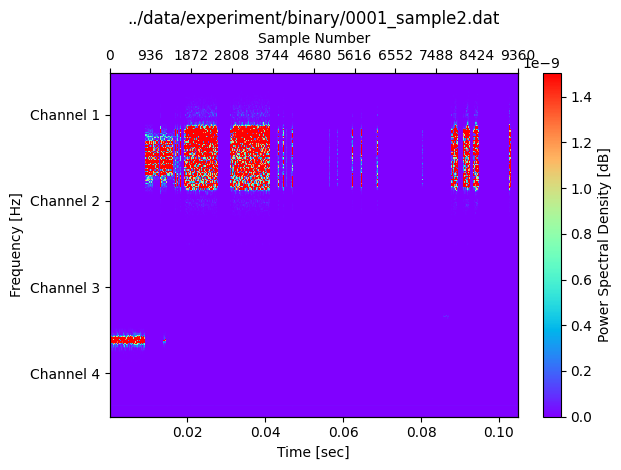

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0001_sample2.dat (shift=2500000 Hz)


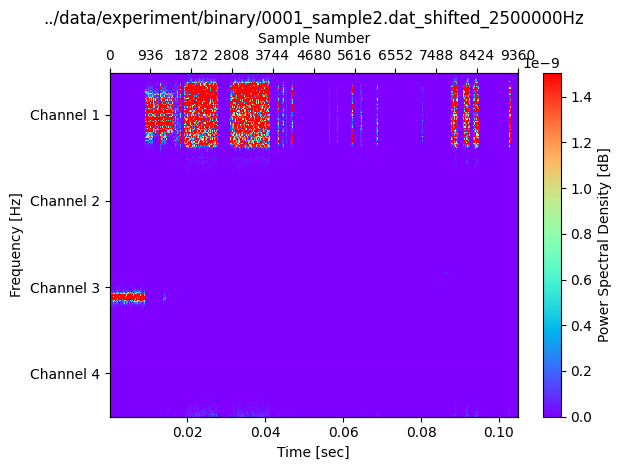

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0001_sample2_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0001_sample3.dat


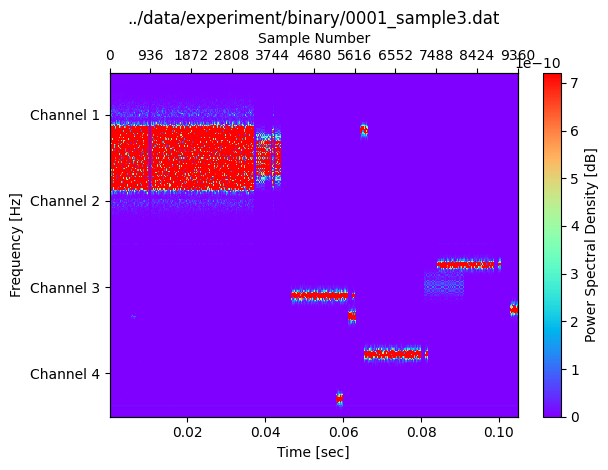

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0001_sample3.dat (shift=2500000 Hz)


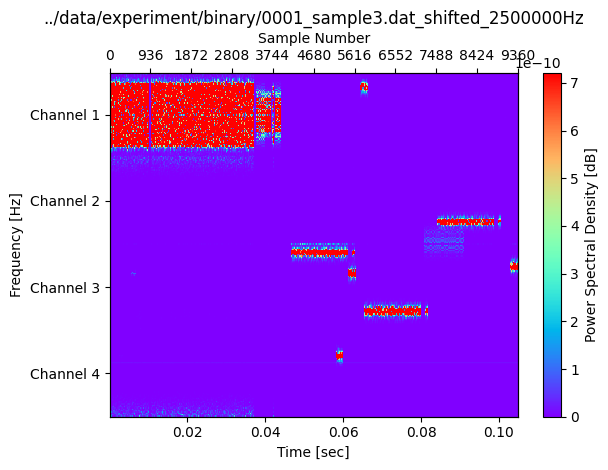

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0001_sample3_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0001_sample4.dat


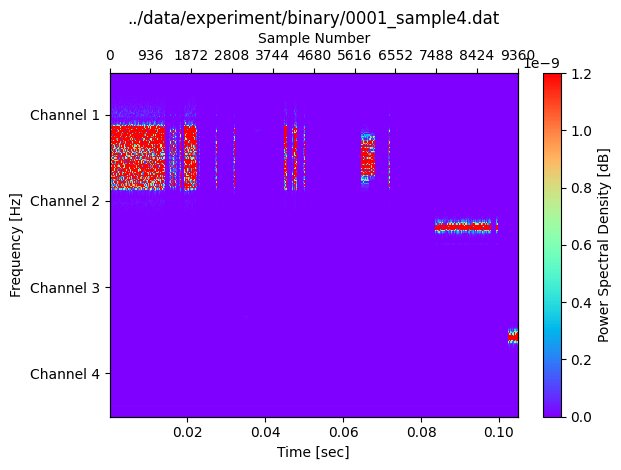

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0001_sample4.dat (shift=2500000 Hz)


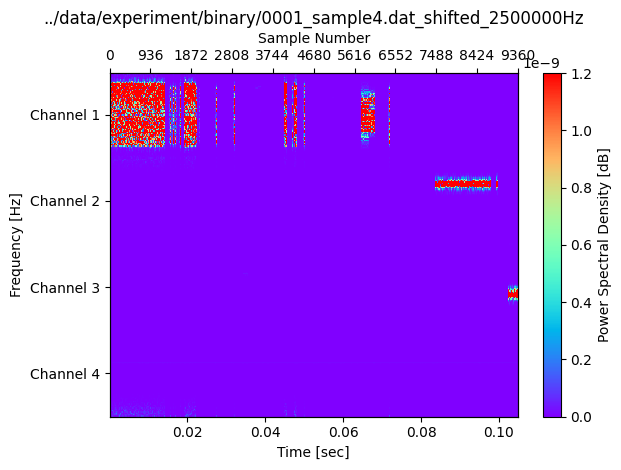

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0001_sample4_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0001_sample5.dat


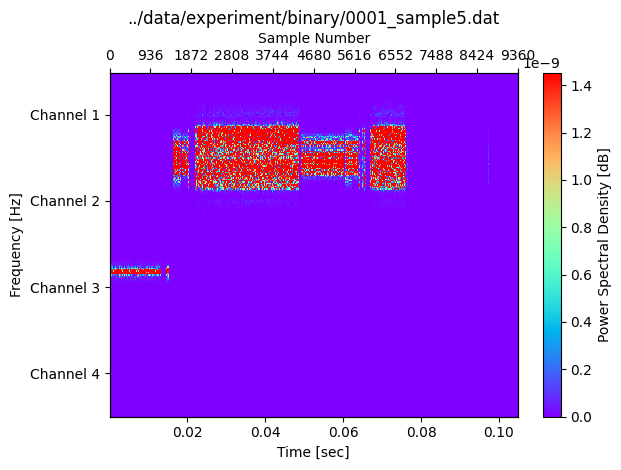

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0001_sample5.dat (shift=2500000 Hz)


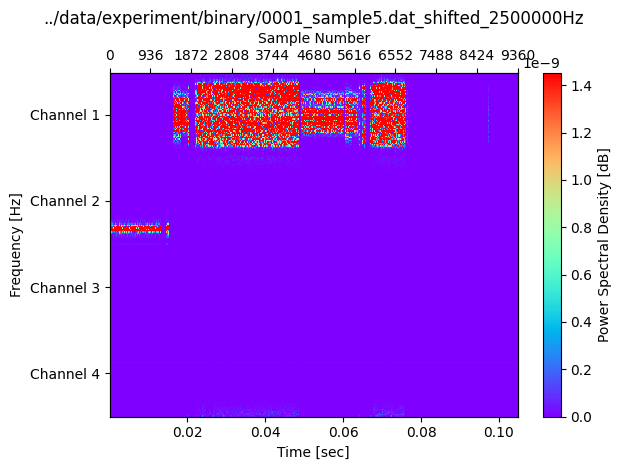

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0001_sample5_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0001_sample5.dat


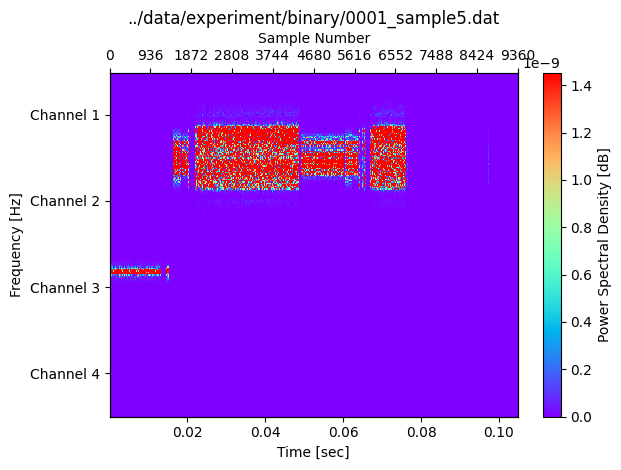

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0001_sample5.dat (shift=2500000 Hz)


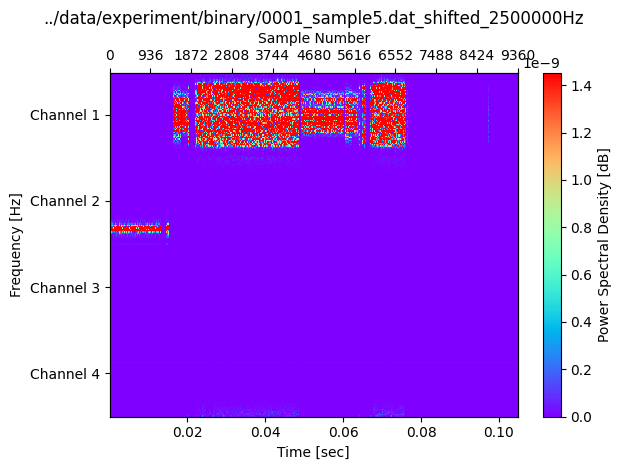

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0001_sample5_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0010_sample1.dat


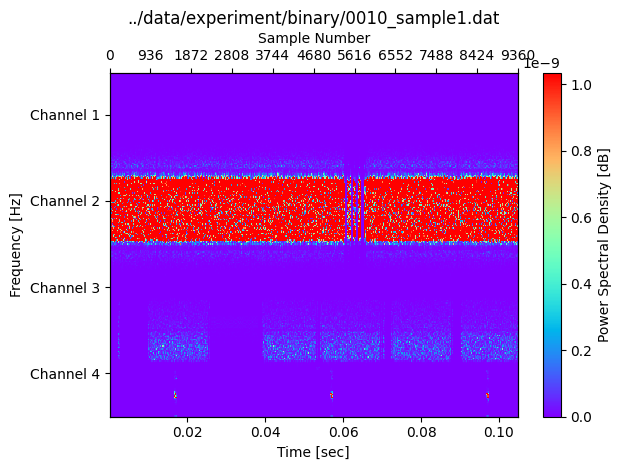

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0010_sample1.dat (shift=500000 Hz)


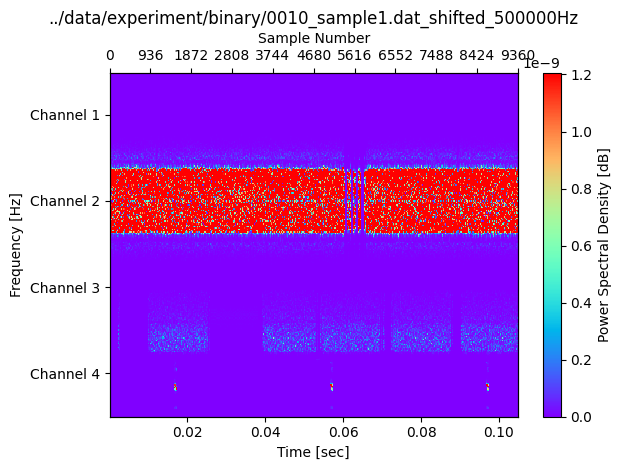

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0010_sample1_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0010_sample3.dat


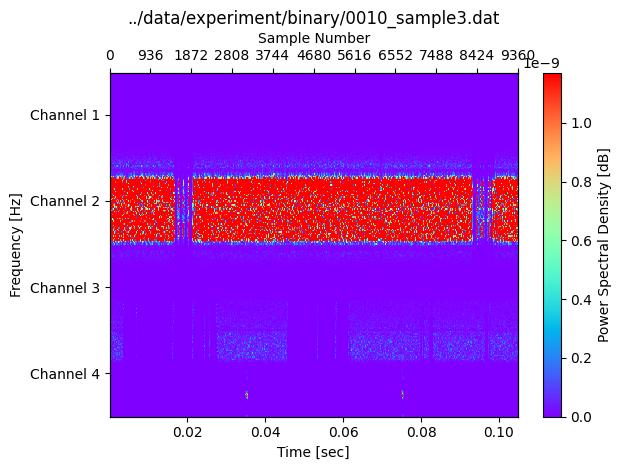

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0010_sample3.dat (shift=500000 Hz)


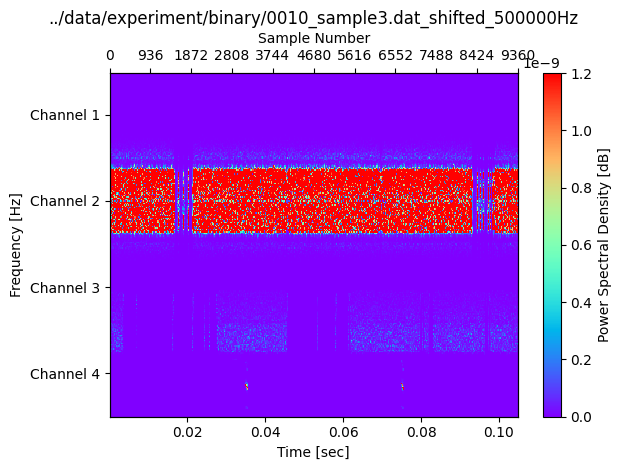

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0010_sample3_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0010_sample4.dat


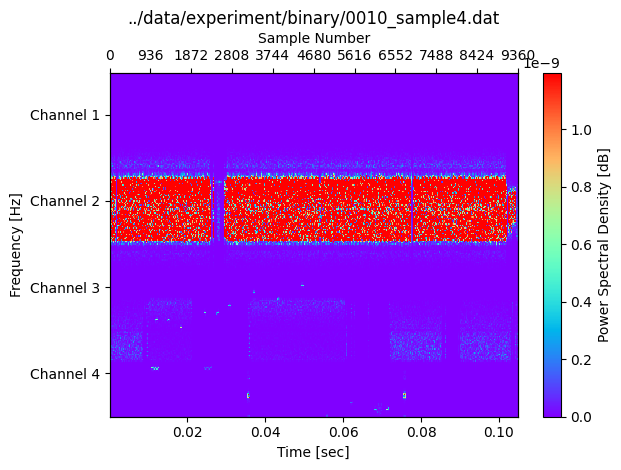

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0010_sample4.dat (shift=500000 Hz)


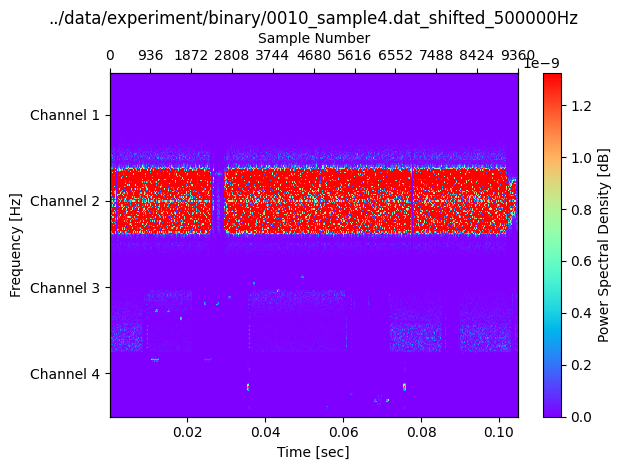

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0010_sample4_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0100_sample1.dat


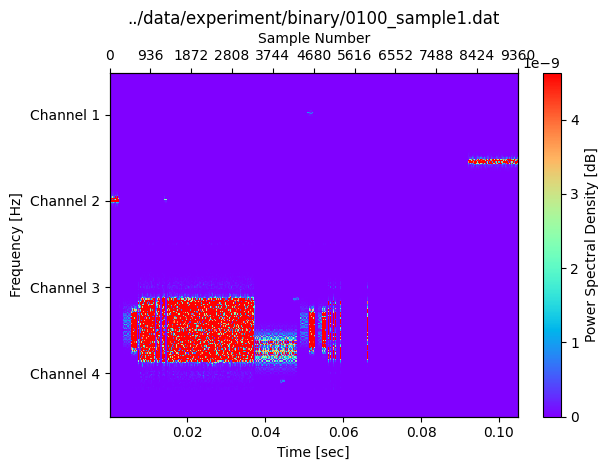

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0100_sample1.dat (shift=2500000 Hz)


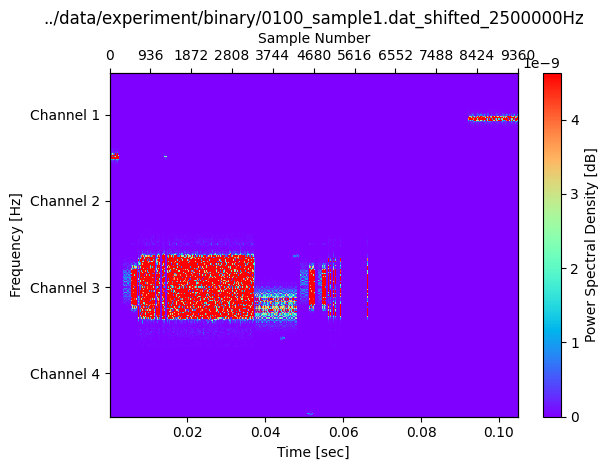

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0100_sample1_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0100_sample2.dat


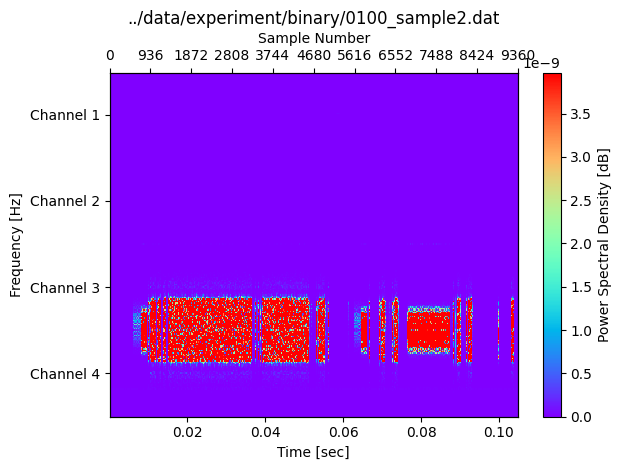

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0100_sample2.dat (shift=2500000 Hz)


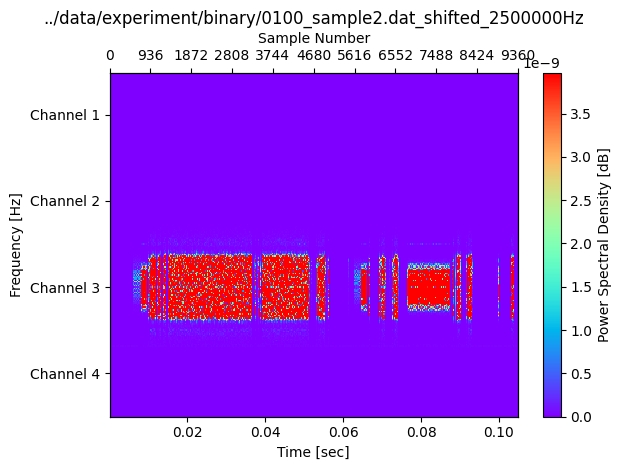

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0100_sample2_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/1000_sample2.dat


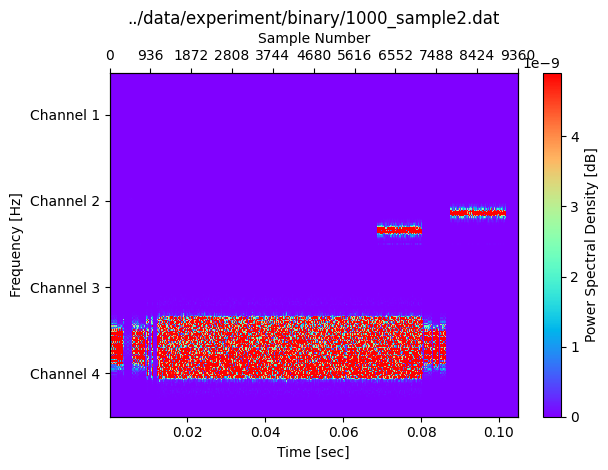

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/1000_sample2.dat (shift=-1000000 Hz)


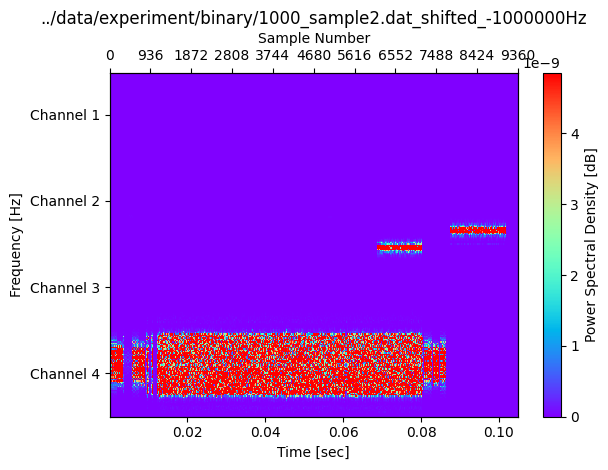

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/1000_sample2_shifted_-1000kHz.dat
Original spectrogram for ../data/experiment/binary/1000_sample3.dat


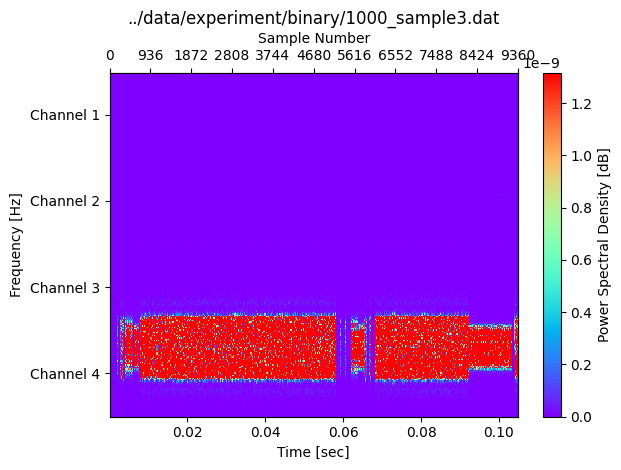

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/1000_sample3.dat (shift=-1000000 Hz)


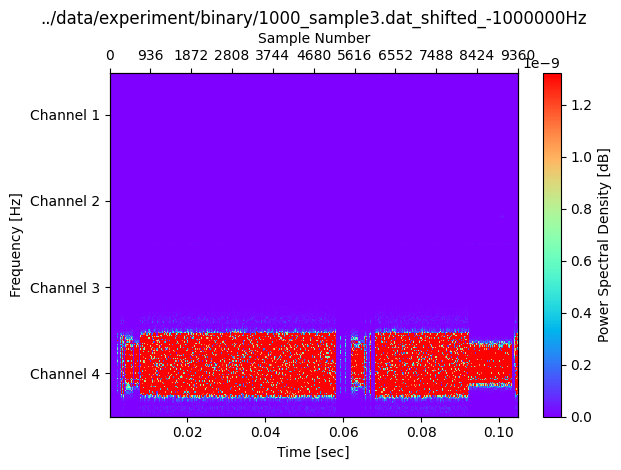

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/1000_sample3_shifted_-1000kHz.dat
Original spectrogram for ../data/experiment/binary/1000_sample4.dat


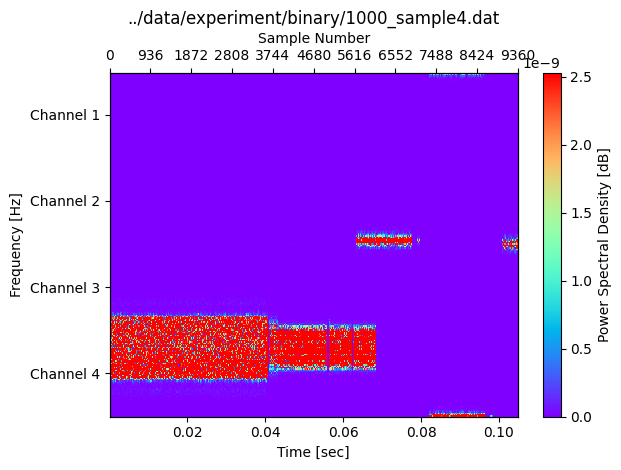

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/1000_sample4.dat (shift=-1000000 Hz)


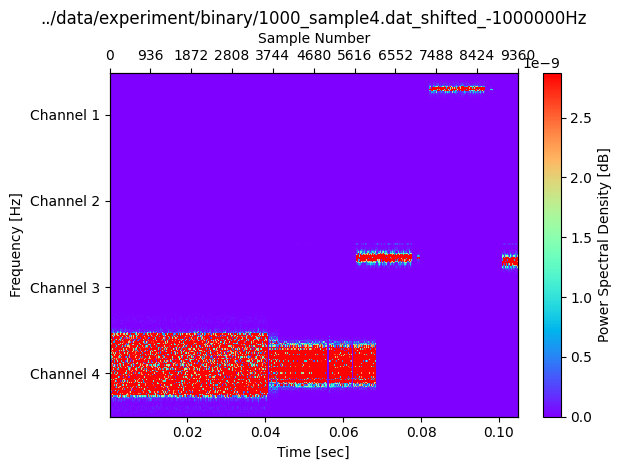

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/1000_sample4_shifted_-1000kHz.dat
Original spectrogram for ../data/experiment/binary/1000_sample5.dat


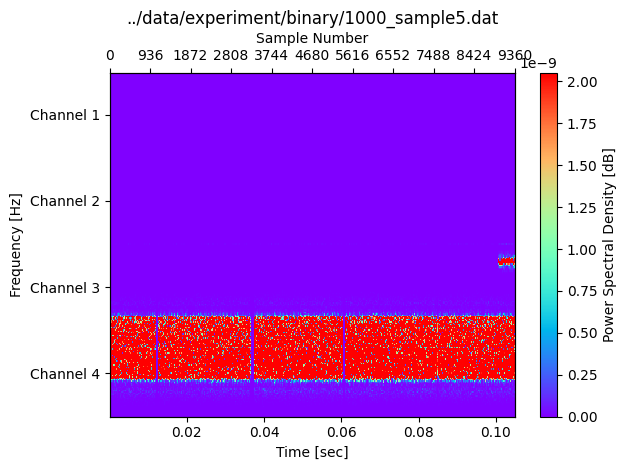

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/1000_sample5.dat (shift=-1000000 Hz)


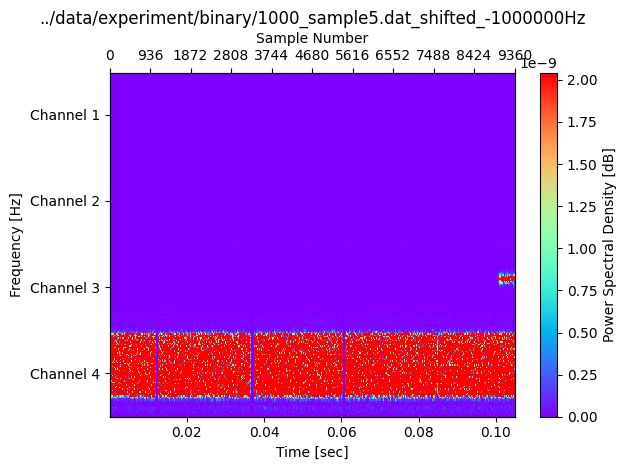

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/1000_sample5_shifted_-1000kHz.dat
Original spectrogram for ../data/experiment/binary/1000_sample6.dat


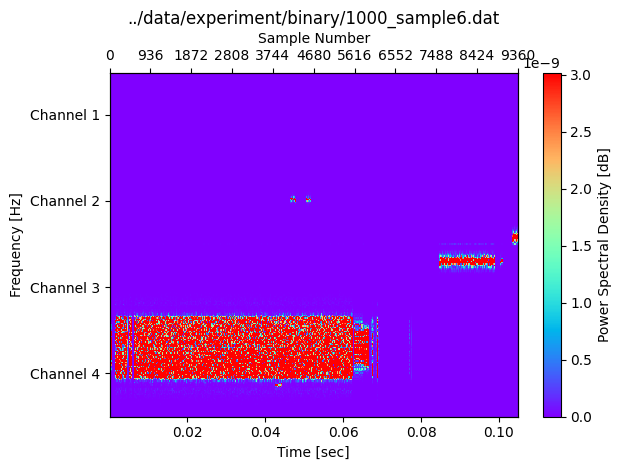

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/1000_sample6.dat (shift=-1000000 Hz)


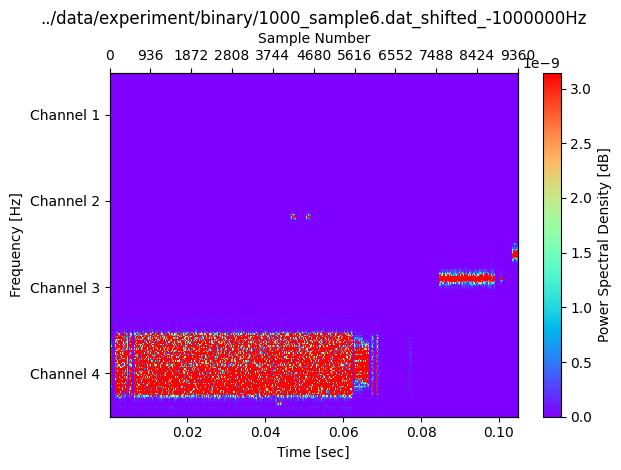

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/1000_sample6_shifted_-1000kHz.dat
Original spectrogram for ../data/experiment/binary/0101_sample1.dat


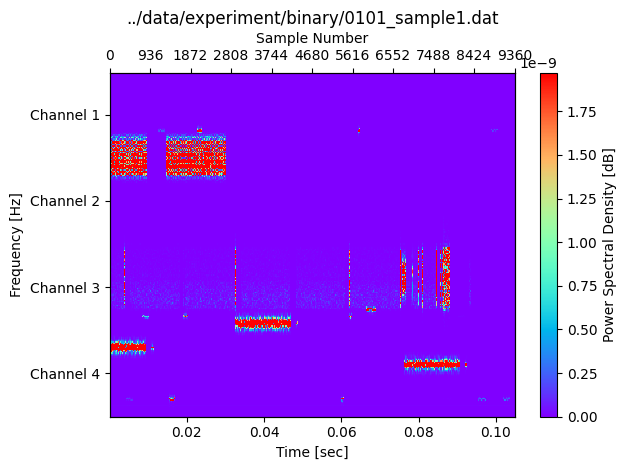

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0101_sample1.dat (shift=2500000 Hz)


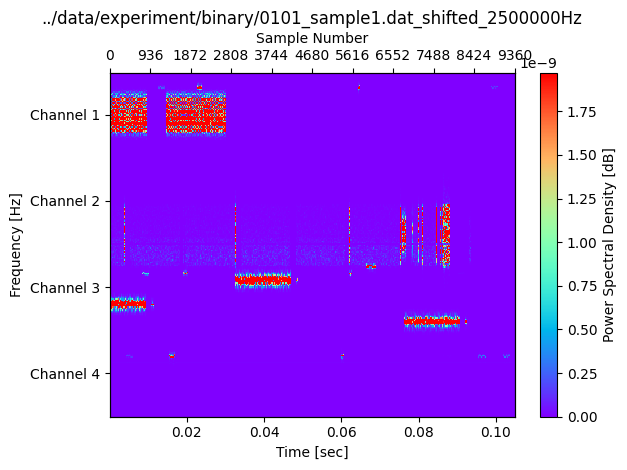

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0101_sample1_shifted_2MHz.dat
Original spectrogram for ../data/experiment/binary/0110_sample2.dat


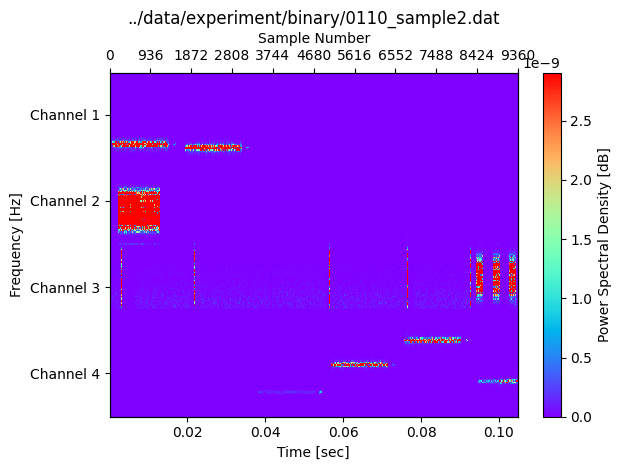

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0110_sample2.dat (shift=500000 Hz)


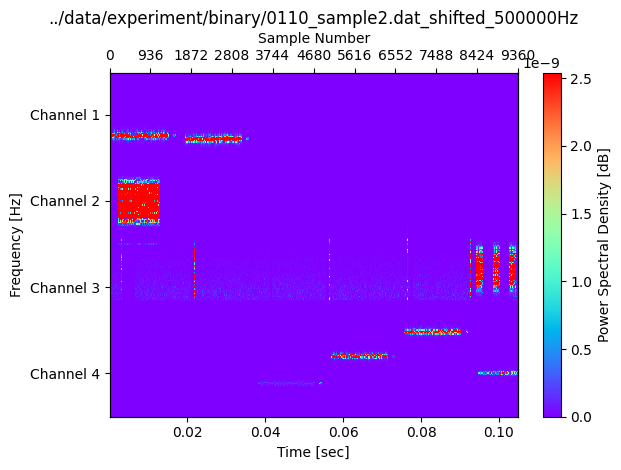

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0110_sample2_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0110_sample3.dat


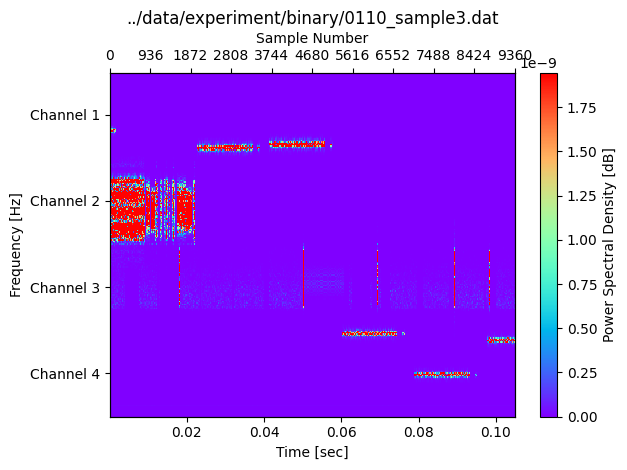

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0110_sample3.dat (shift=500000 Hz)


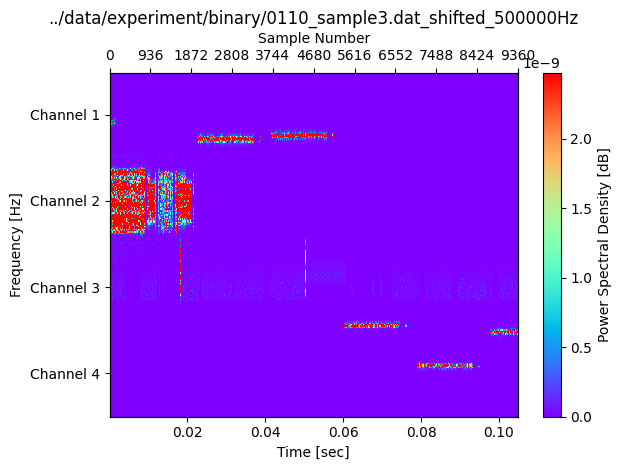

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0110_sample3_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0110_sample4.dat


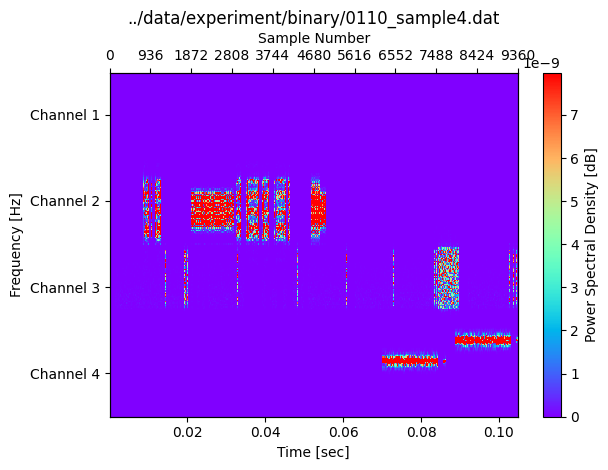

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0110_sample4.dat (shift=500000 Hz)


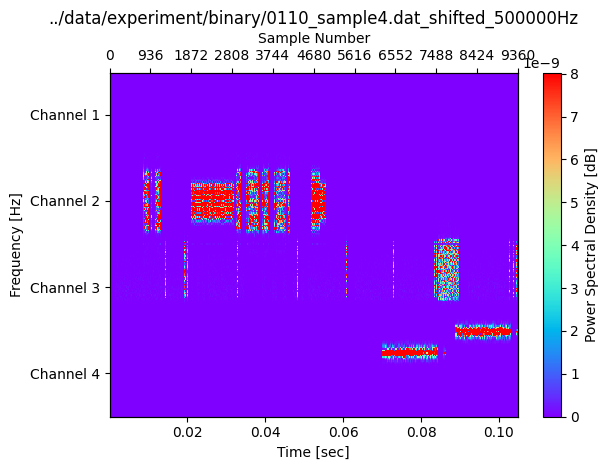

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0110_sample4_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0110_sample6.dat


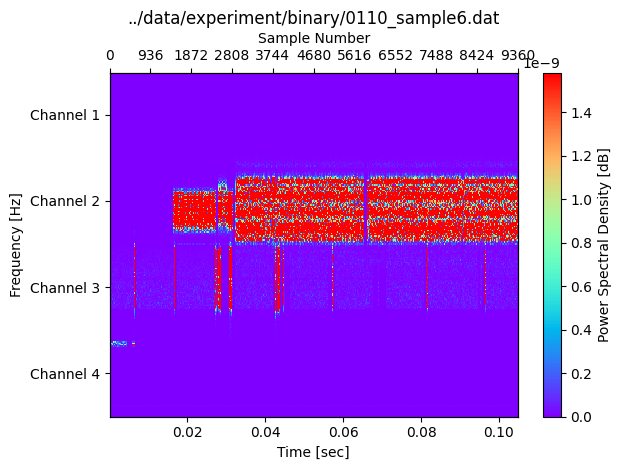

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0110_sample6.dat (shift=500000 Hz)


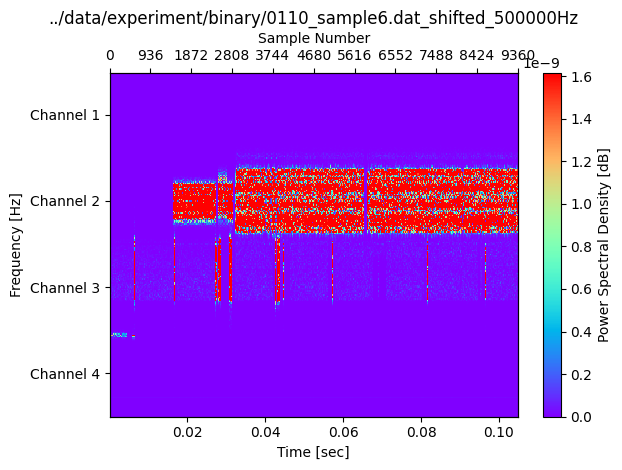

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0110_sample6_shifted_500kHz.dat
Original spectrogram for ../data/experiment/binary/0110_sample7.dat


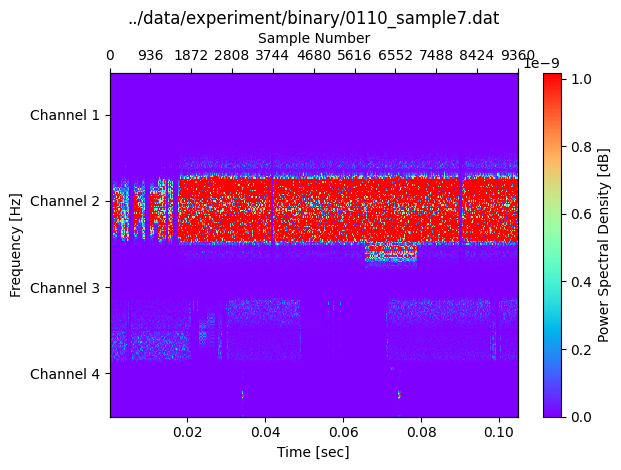

<Figure size 640x480 with 0 Axes>

Shifted spectrogram for ../data/experiment/binary/0110_sample7.dat (shift=500000 Hz)


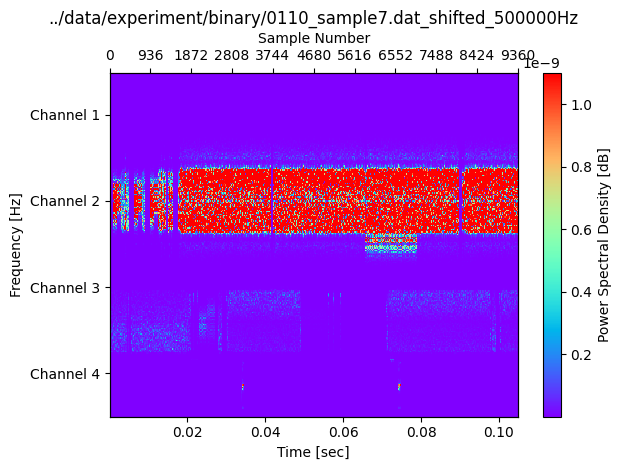

<Figure size 640x480 with 0 Axes>

Shifted samples saved to ../data/experiment/binary/0110_sample7_shifted_500kHz.dat


In [107]:
bin_files = [
    (os.path.join(DIRECTORY, filename), shift_hz) for filename, shift_hz in FILES
]

shift_results = []

# Example usage: process and save shifted IQ samples for all files
for file_tuple in bin_files:
    filepath, shift_hz = file_tuple

    shifted = process_and_plot_shift(filepath, shift_hz=shift_hz)
    new_filepath = save_shifted_samples(filepath, shifted, shift_hz=shift_hz)

    shift_results.append(new_filepath)

['../data/experiment/binary/0001_sample1.dat', '../data/experiment/binary/1000_sample1.dat', '../data/experiment/binary/1000_sample8.dat', '../data/experiment/binary/0001_sample2_shifted_2MHz.dat', '../data/experiment/binary/0001_sample3_shifted_2MHz.dat', '../data/experiment/binary/0001_sample4_shifted_2MHz.dat', '../data/experiment/binary/0001_sample5_shifted_2MHz.dat', '../data/experiment/binary/0001_sample5_shifted_2MHz.dat', '../data/experiment/binary/0010_sample1_shifted_500kHz.dat', '../data/experiment/binary/0010_sample3_shifted_500kHz.dat', '../data/experiment/binary/0010_sample4_shifted_500kHz.dat', '../data/experiment/binary/0100_sample1_shifted_2MHz.dat', '../data/experiment/binary/0100_sample2_shifted_2MHz.dat', '../data/experiment/binary/1000_sample2_shifted_-1000kHz.dat', '../data/experiment/binary/1000_sample3_shifted_-1000kHz.dat', '../data/experiment/binary/1000_sample4_shifted_-1000kHz.dat', '../data/experiment/binary/1000_sample5_shifted_-1000kHz.dat', '../data/expe

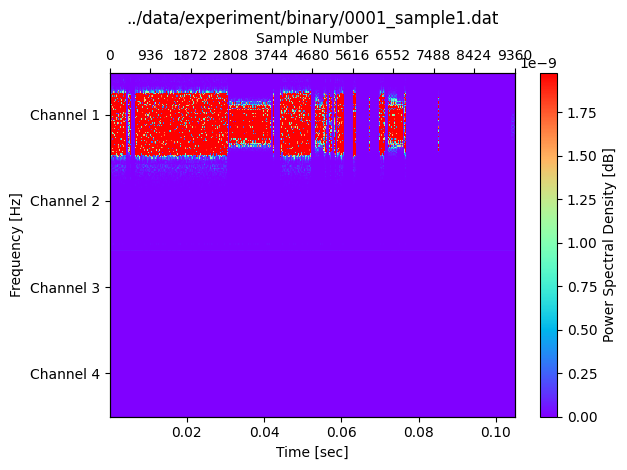

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample1.dat


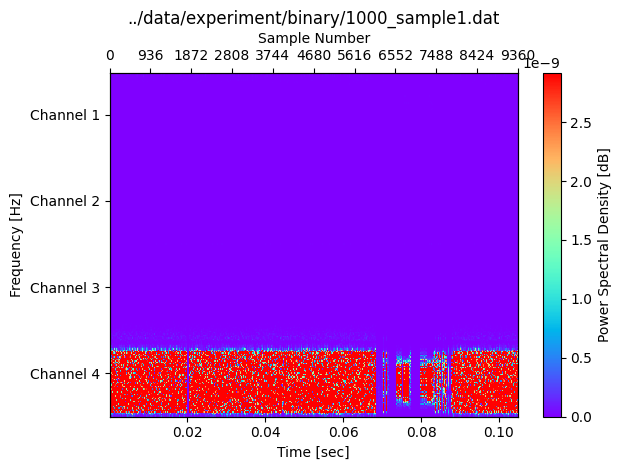

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample8.dat


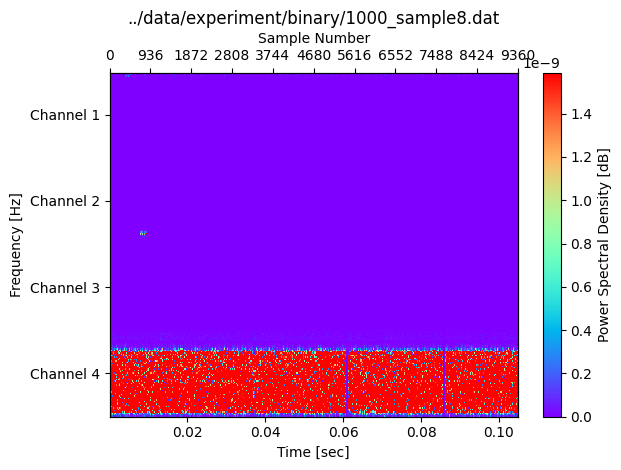

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0001_sample2_shifted_2MHz.dat


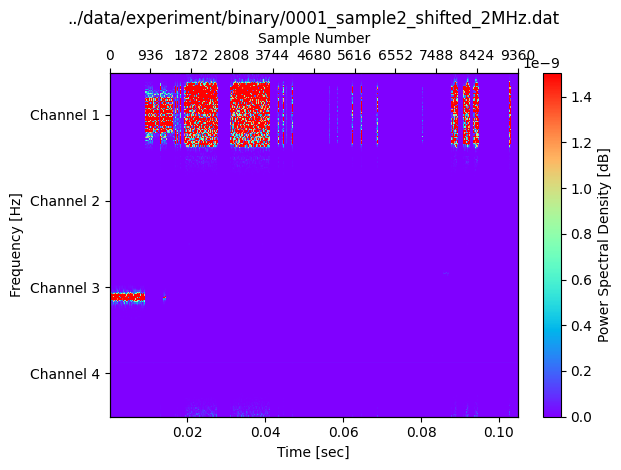

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0001_sample3_shifted_2MHz.dat


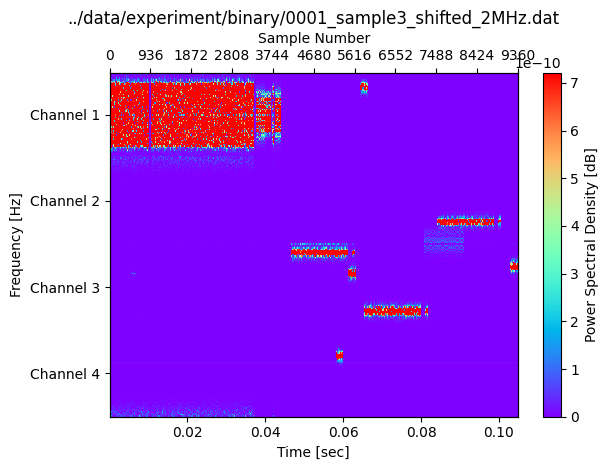

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0001_sample4_shifted_2MHz.dat


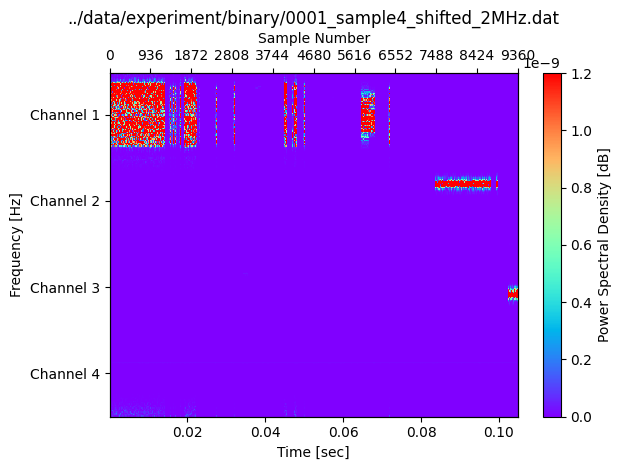

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0001_sample5_shifted_2MHz.dat


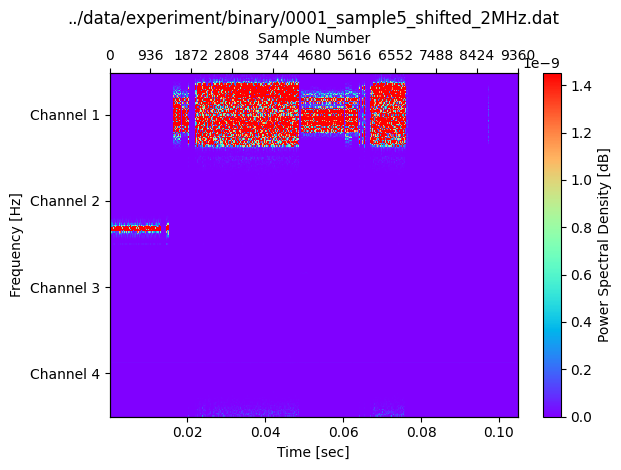

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0001_sample5_shifted_2MHz.dat


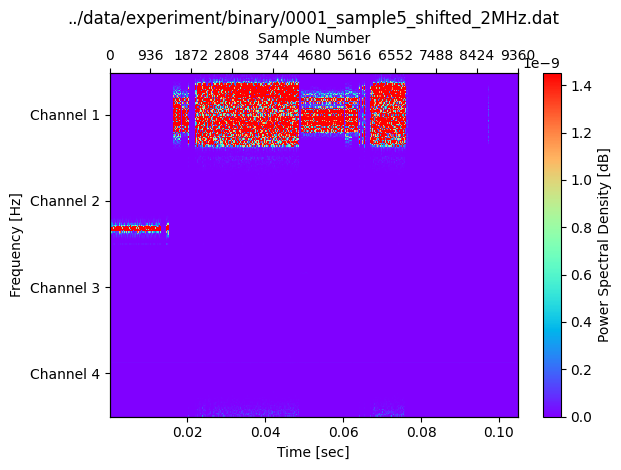

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0010_sample1_shifted_500kHz.dat


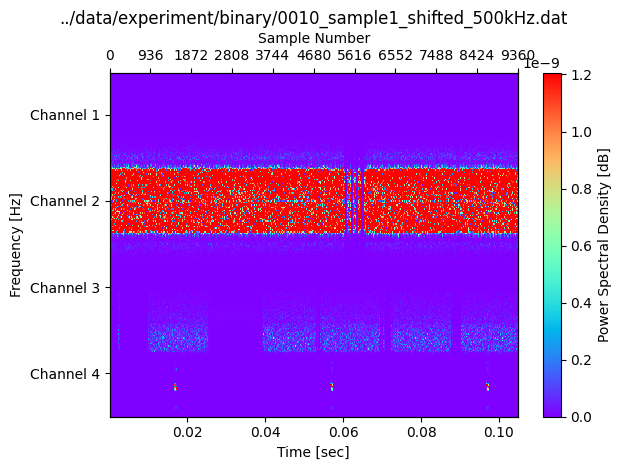

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0010_sample3_shifted_500kHz.dat


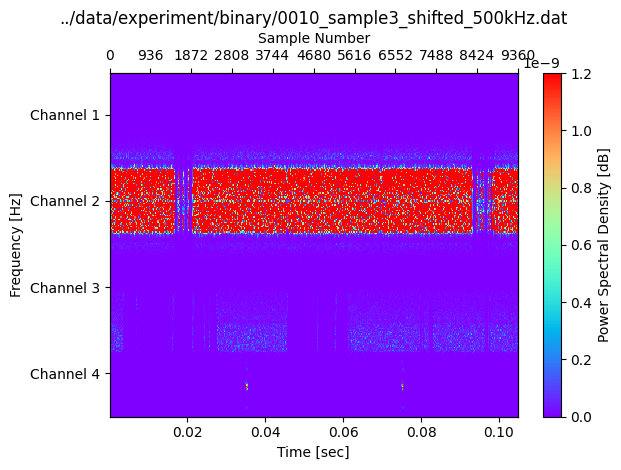

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0010_sample4_shifted_500kHz.dat


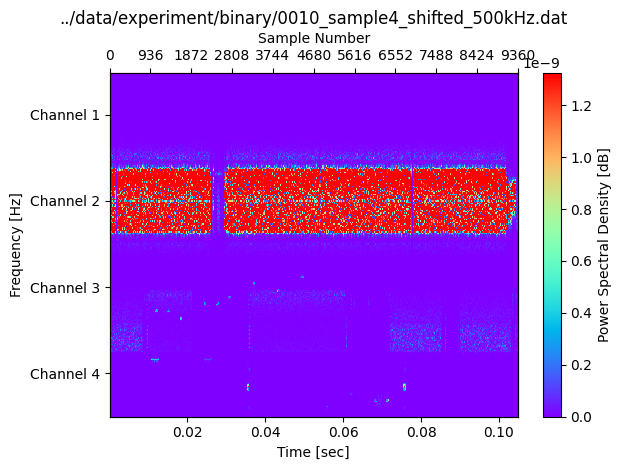

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0100_sample1_shifted_2MHz.dat


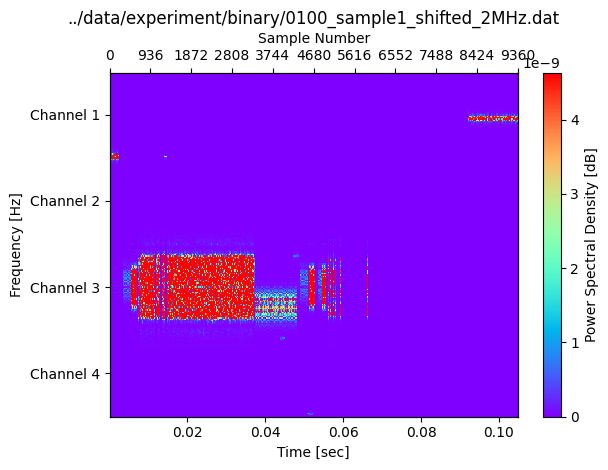

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0100_sample2_shifted_2MHz.dat


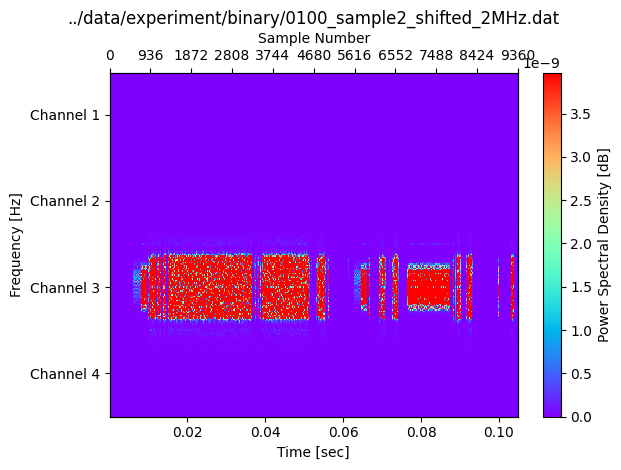

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample2_shifted_-1000kHz.dat


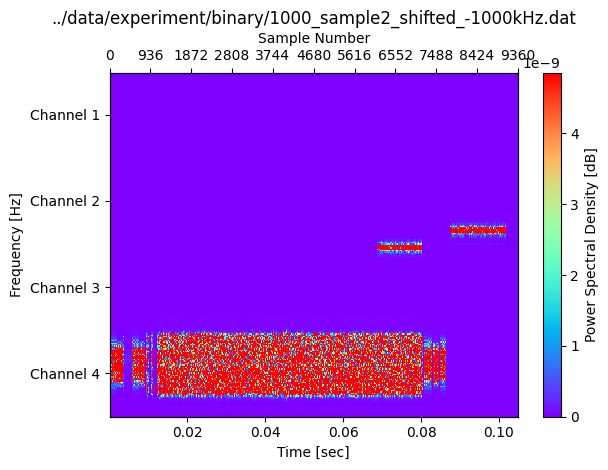

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample3_shifted_-1000kHz.dat


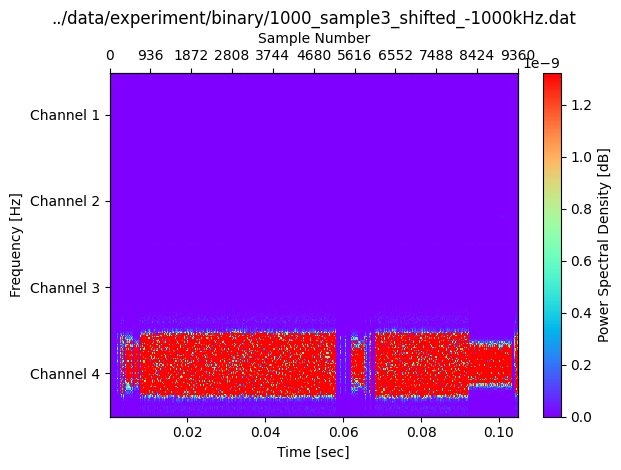

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample4_shifted_-1000kHz.dat


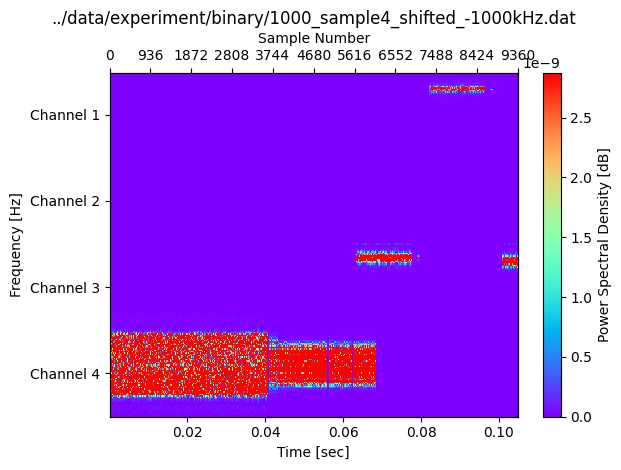

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample5_shifted_-1000kHz.dat


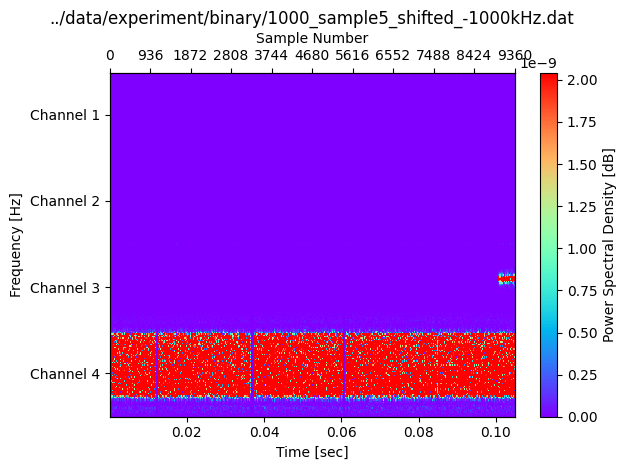

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/1000_sample6_shifted_-1000kHz.dat


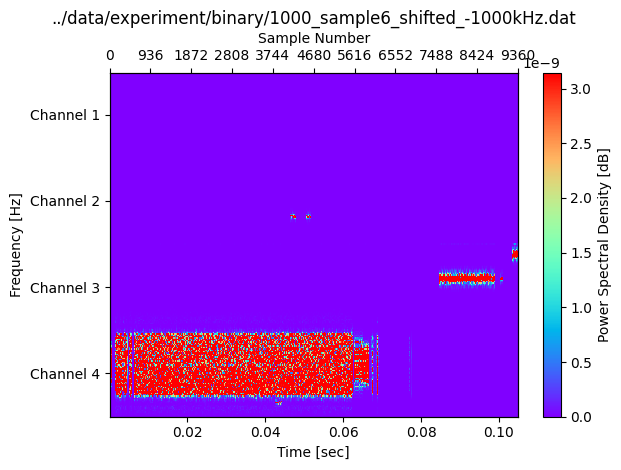

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0101_sample1_shifted_2MHz.dat


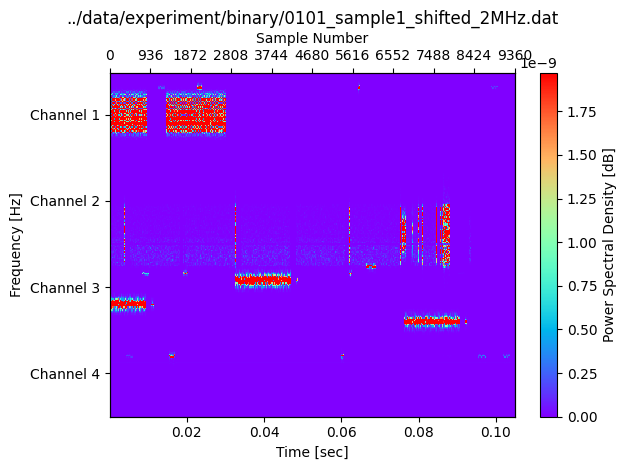

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0110_sample2_shifted_500kHz.dat


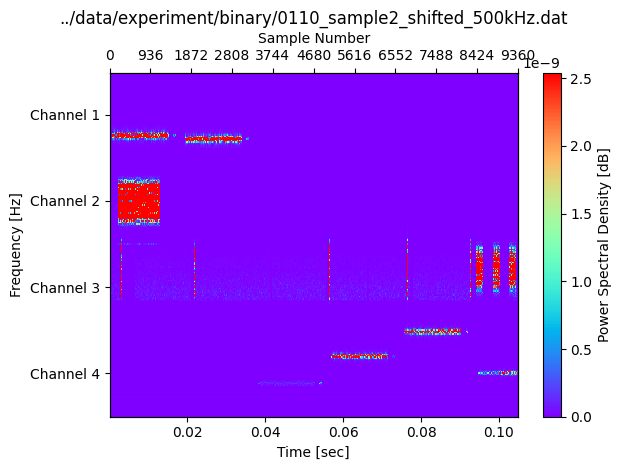

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0110_sample3_shifted_500kHz.dat


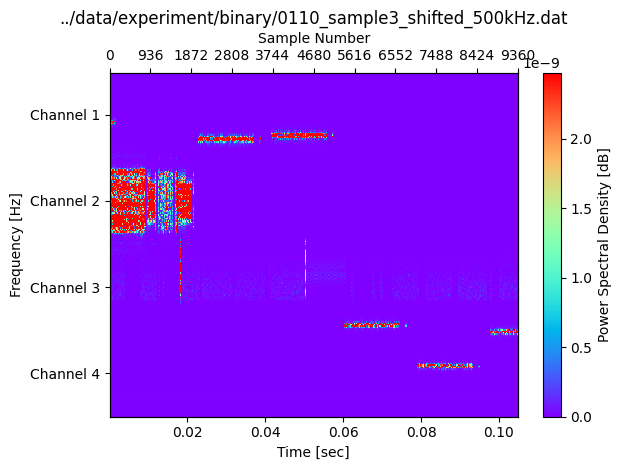

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0110_sample4_shifted_500kHz.dat


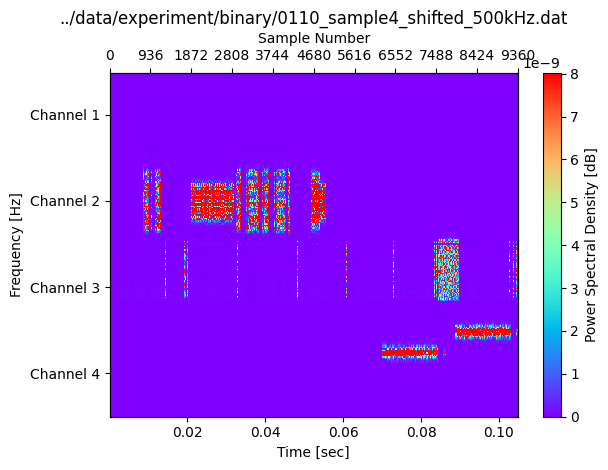

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0110_sample6_shifted_500kHz.dat


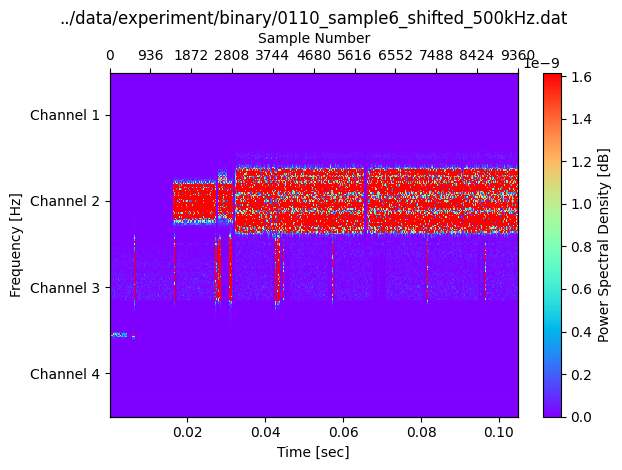

<Figure size 640x480 with 0 Axes>

Spectrogram for ../data/experiment/binary/0110_sample7_shifted_500kHz.dat


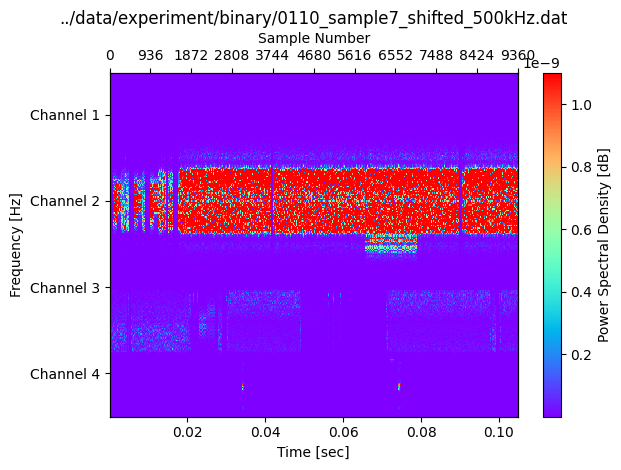

<Figure size 640x480 with 0 Axes>

In [108]:
# Plot all good files and shifted files to verify results
good_bin_files = [
    os.path.join(DIRECTORY, f) for f in GOOD_FILES if f.endswith('.dat')
]

print(good_bin_files + shift_results)

for filepath in good_bin_files + shift_results:
    with open(filepath, 'rb') as binary_file:
        samps = np.fromfile(binary_file, dtype=np.complex64)
        
    print(f"Spectrogram for {filepath}")
    plot_spectrogram(filepath, samps)